In [1]:
from openai import OpenAI
import dotenv
import base64
import os
import glob
from PIL import Image



In [2]:
dotenv.load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

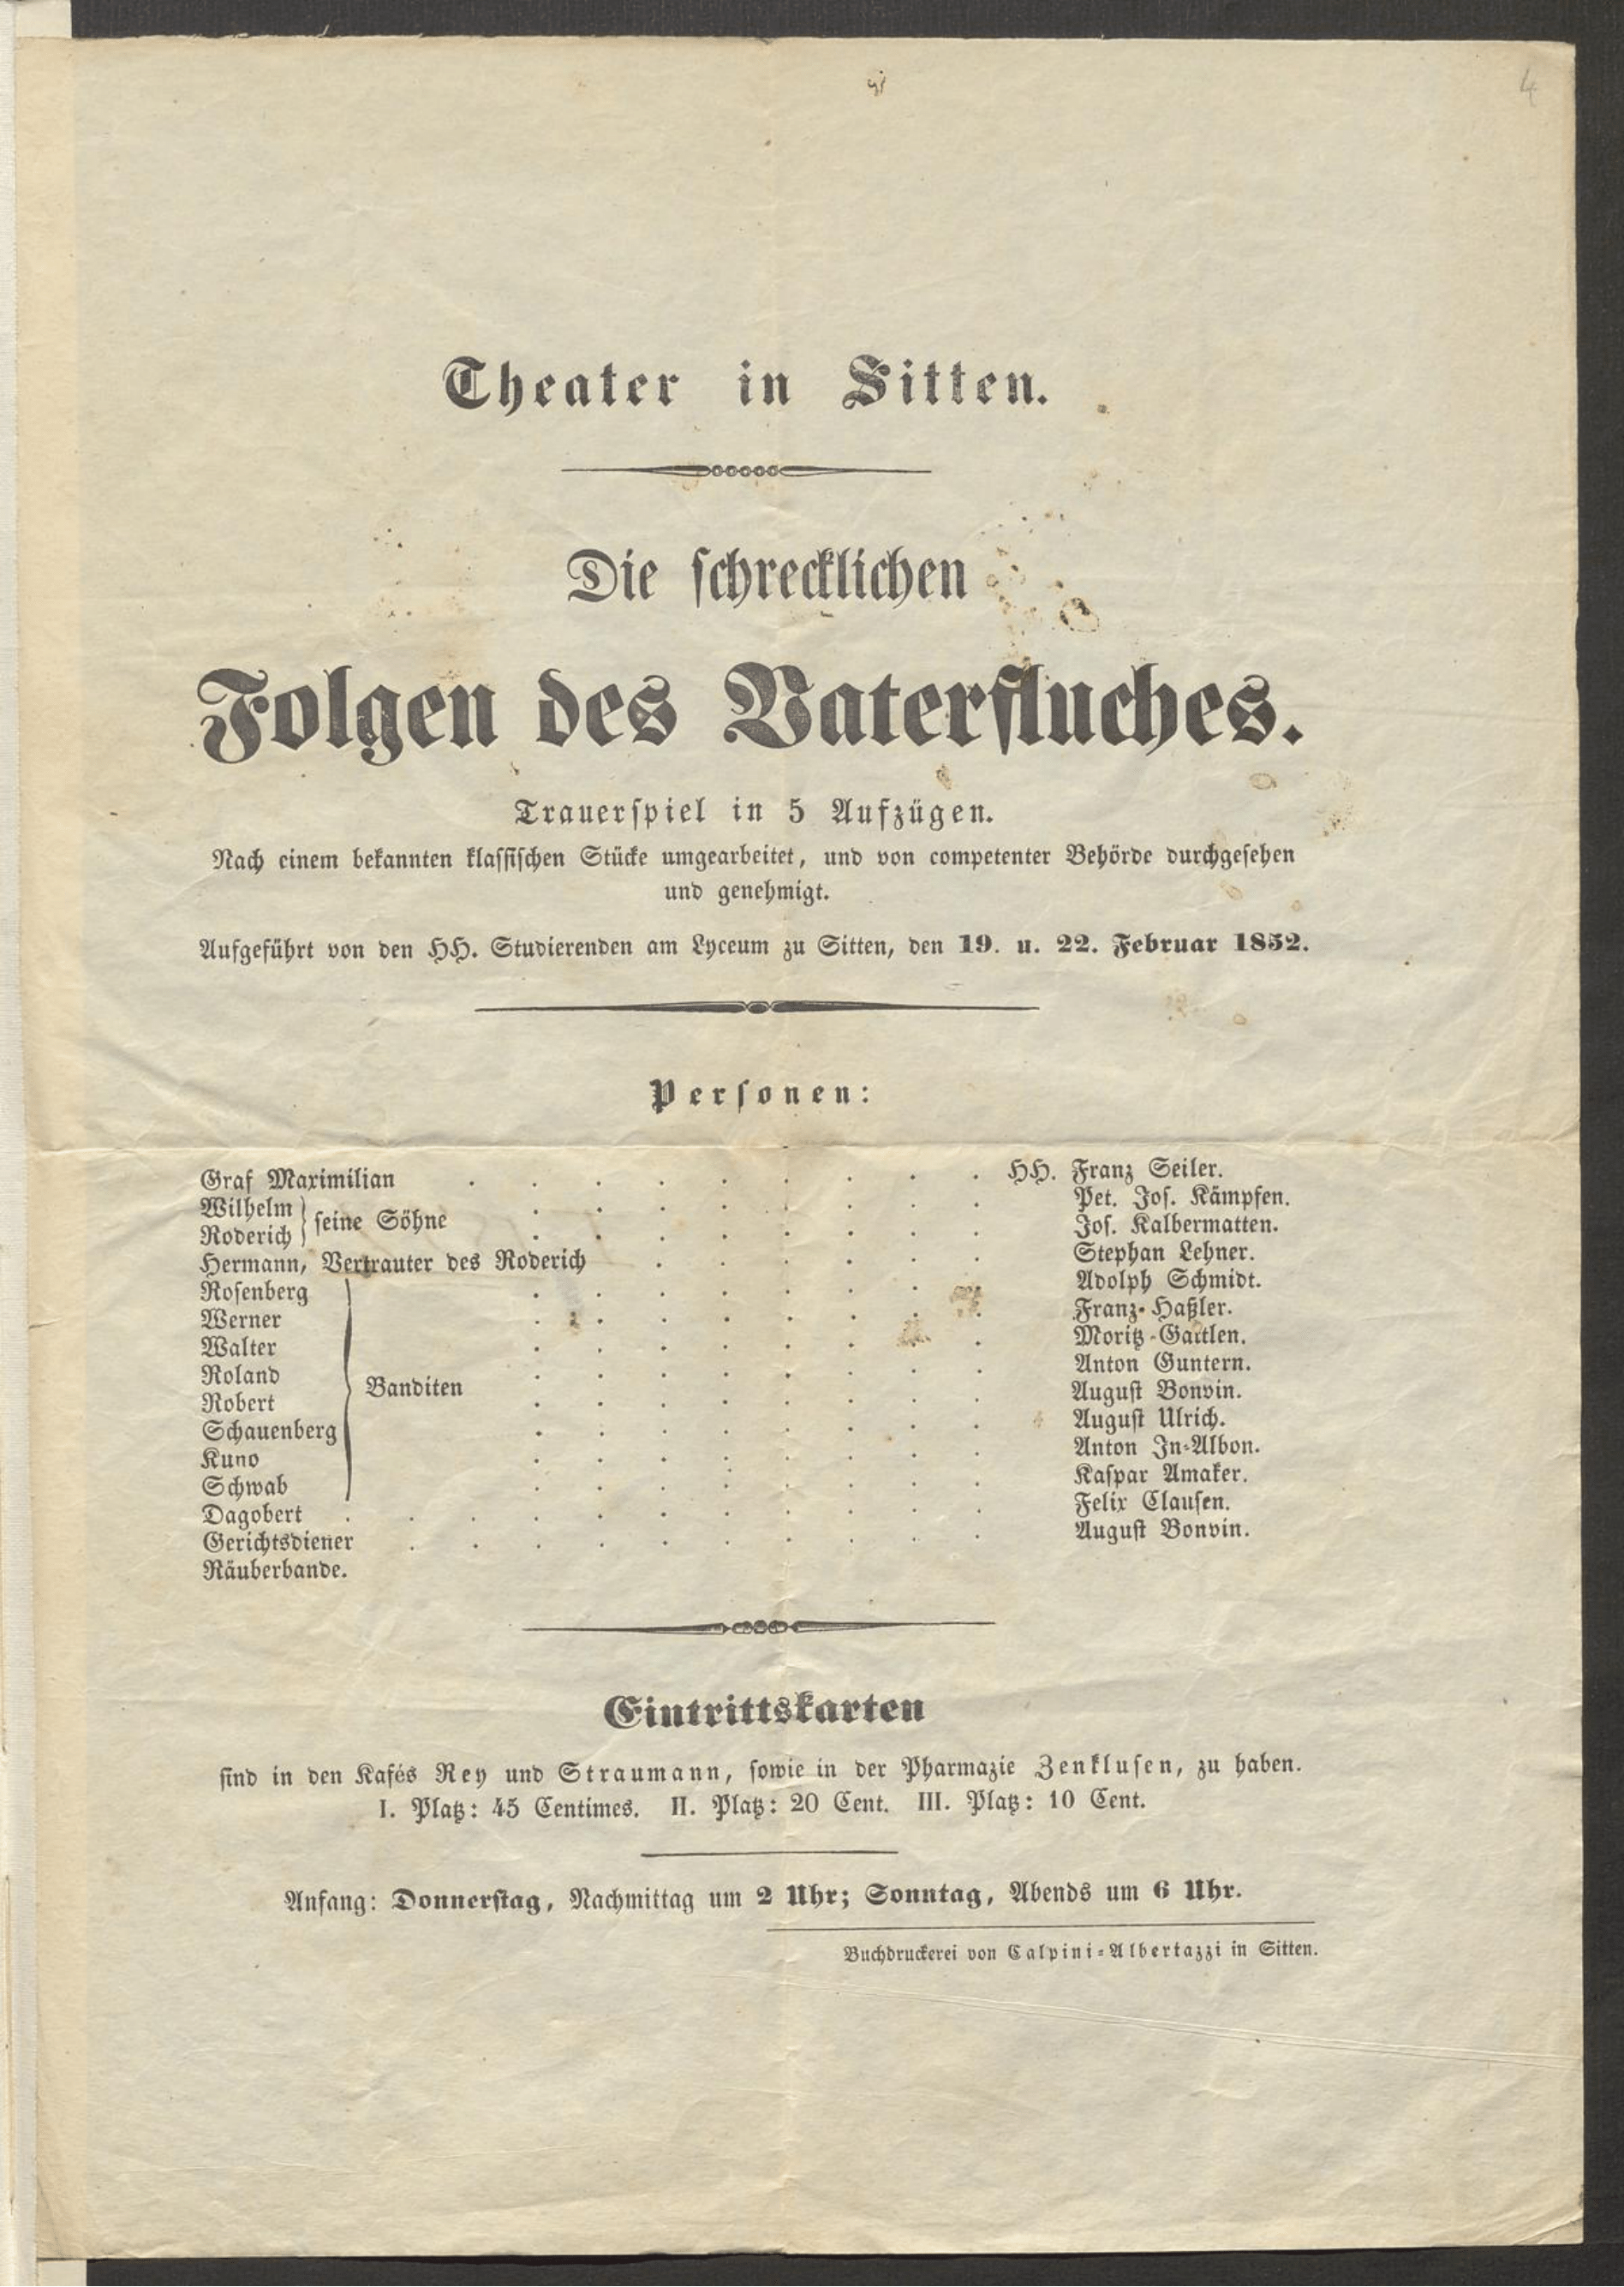

In [3]:
img_path = "../data/ankuendigung_1852.png"
im = Image.open(img_path)
im

In [11]:
json_schema = {
    "name": "theater_information",
    "schema": {
        "type": "object",
        "properties": {
            "title": {
                "type": "string"
            },
            "actors": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {"type": "string"},
                        "role": {"type": "string"}
                    },
                    "required": ["name", "role"],
                    "additionalProperties": False
                }
            },
            "played_when": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "date": {"type": "string"},
                        "start_time": {"type": "string"},
                        "place": {"type": "string"}
                    },
                    "required": ["date", "start_time", "place"],
                    "additionalProperties": False
                }
            }
        },
        "required": ["title", "actors", "played_when"],
        "additionalProperties": False
    },
    "strict": True
}


In [5]:
with open(img_path, "rb") as f:
        image_data = f.read()
    
base64_image = base64.b64encode(image_data).decode("utf-8")

In [9]:
prompt = """
        Bitte aus dem Bild die Information extrahieren. 
        Das Datum soll in Form von YYYY-MM-DD geschrieben werden. 
        Die Uhrzeit soll hh:mm verfasst werden. 
        """

In [12]:
response = client.chat.completions.create(
    model="gpt-4.1",
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{base64_image}"
                }
            },
        ],
    }],
    response_format={
        "type": "json_schema",
        "json_schema": json_schema
    }
)



In [16]:
print(response.choices[0].message.content)


{
  "title": "Die schrecklichen Folgen des Vatersfluches",
  "actors": [
    {"name": "Franz Seiler", "role": "Graf Maximilian"},
    {"name": "Petr. Jos. Kampfen", "role": "Wilhelm"},
    {"name": "Jos. Kalbermatten", "role": "Roderich"},
    {"name": "Stephan Lehner", "role": "Hermann"},
    {"name": "Adolph Schmid", "role": "Rosenberg"},
    {"name": "Franz Hafner", "role": "Werner"},
    {"name": "Moritz Gautlen", "role": "Walter"},
    {"name": "Anton Guntern", "role": "Roland"},
    {"name": "August Bondin", "role": "Robert"},
    {"name": "August Ulrich", "role": "Schaunenberg"},
    {"name": "Anton An-Mabon", "role": "Tuno"},
    {"name": "Kaspar Amser", "role": "Erichhof"},
    {"name": "Felix Clausen", "role": "Dagobert"},
    {"name": "August Bondin", "role": "Gerichtsbeisitzer"},
    {"name": "", "role": "Räuberbande"}
  ],
  "played_when": [
    {
      "date": "1852-02-19",
      "start_time": "14:00",
      "place": "Lyceum zu Sitten"
    },
    {
      "date": "1852-02-